## **1. Import Required Library**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor

## **2. Load the Dataset**

In [6]:
df = pd.read_csv(r"C:\Users\ABXREHMAN\Documents\ML-2026\Projects\London_House\london_houses.csv")

In [7]:
df.head()

,Address,Neighborhood,Bedrooms,Bathrooms,Square Meters,Building Age,Garden,Garage,Floors,Property Type,Heating Type,Balcony,Interior Style,View,Materials,Building Status,Price (£)
0,78 Regent Street,Notting Hill,2,3,179,72,No,No,3,Semi-Detached,Electric Heating,High-level Balcony,Industrial,Garden,Marble,Renovated,2291200
1,198 Oxford Street,Westminster,2,1,123,34,Yes,No,1,Apartment,Central Heating,High-level Balcony,Industrial,City,Laminate Flooring,Old,1476000
2,18 Regent Street,Soho,5,3,168,38,No,Yes,3,Semi-Detached,Central Heating,No Balcony,Industrial,Street,Wood,Renovated,1881600
3,39 Piccadilly Circus,Islington,5,1,237,53,Yes,Yes,1,Apartment,Underfloor Heating,No Balcony,Classic,Park,Granite,Renovated,1896000
4,116 Fleet Street,Marylebone,4,1,127,23,No,Yes,2,Semi-Detached,Central Heating,No Balcony,Modern,Park,Wood,Old,1524000


In [8]:
df.shape

(1000, 17)

In [9]:
df.isna().sum()

Address            0
Neighborhood       0
Bedrooms           0
Bathrooms          0
Square Meters      0
Building Age       0
Garden             0
Garage             0
Floors             0
Property Type      0
Heating Type       0
Balcony            0
Interior Style     0
View               0
Materials          0
Building Status    0
Price (£)          0
dtype: int64

## **3. Data Visualization**

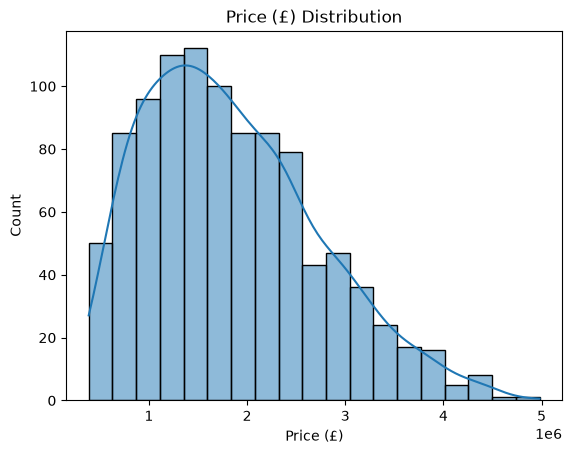

In [10]:
# Price distribution
plt.figure()
sns.histplot(df["Price (£)"], kde=True)
plt.title("Price (£) Distribution")
plt.xlabel("Price (£)")
plt.show()

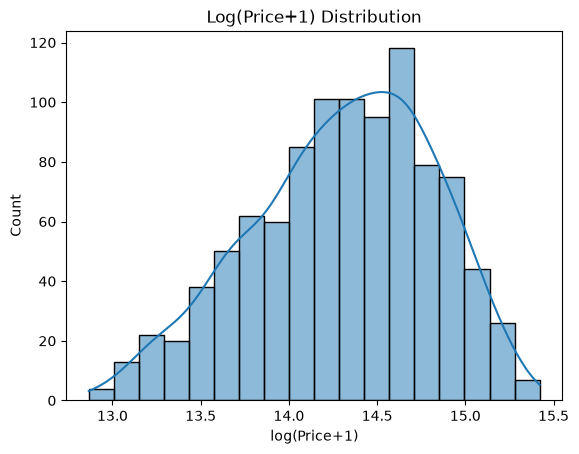

In [11]:
# Log-Price distribution 
plt.figure()
sns.histplot(np.log1p(df["Price (£)"]), kde=True)
plt.title("Log(Price+1) Distribution")
plt.xlabel("log(Price+1)")
plt.show()

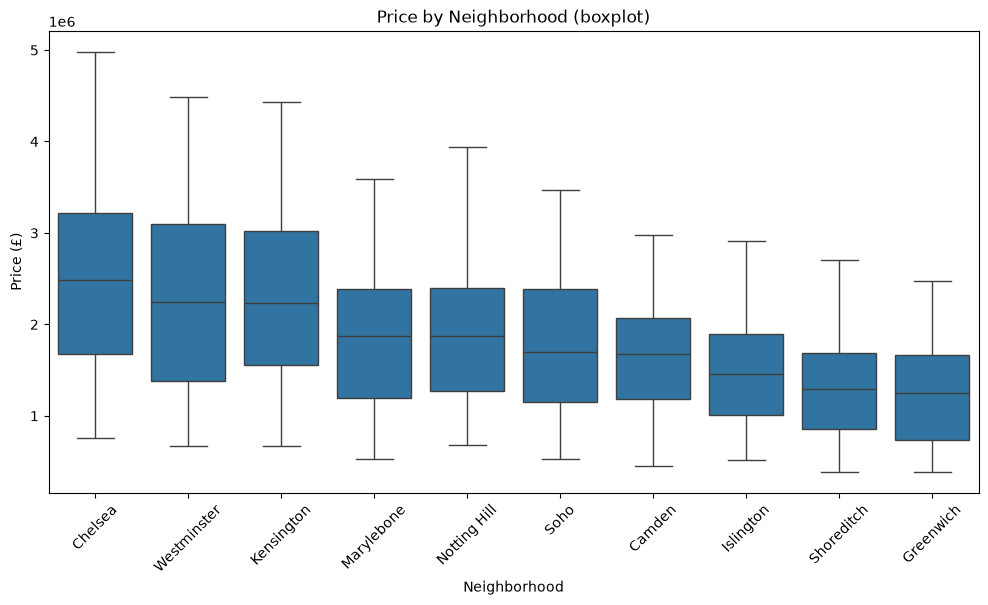

In [12]:
# Boxplot: Price by Neighborhood
plt.figure(figsize=(12,6))
order = df.groupby("Neighborhood")["Price (£)"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="Neighborhood", y="Price (£)", order=order)
plt.xticks(rotation=45)
plt.title("Price by Neighborhood (boxplot)")
plt.show()

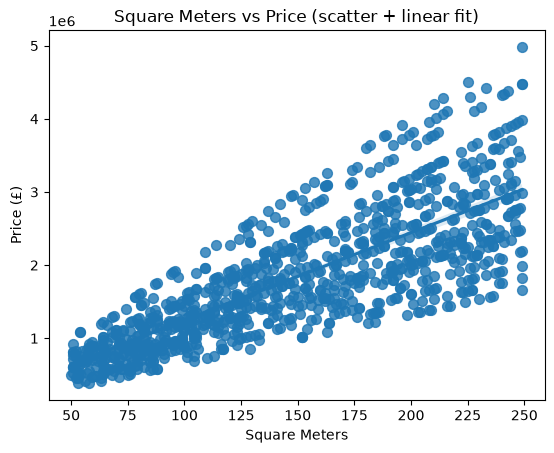

In [13]:
# Scatter plot: Square Meters vs Price (with regression line)
plt.figure()
sns.regplot(data=df, x="Square Meters", y="Price (£)", scatter_kws={"s":50})
plt.title("Square Meters vs Price (scatter + linear fit)")
plt.show()

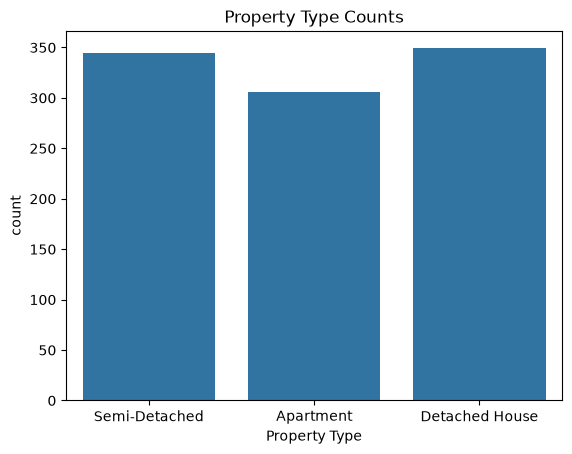

In [14]:
# Countplot of Property Type
plt.figure()
sns.countplot(data=df, x="Property Type")
plt.title("Property Type Counts")
plt.show()

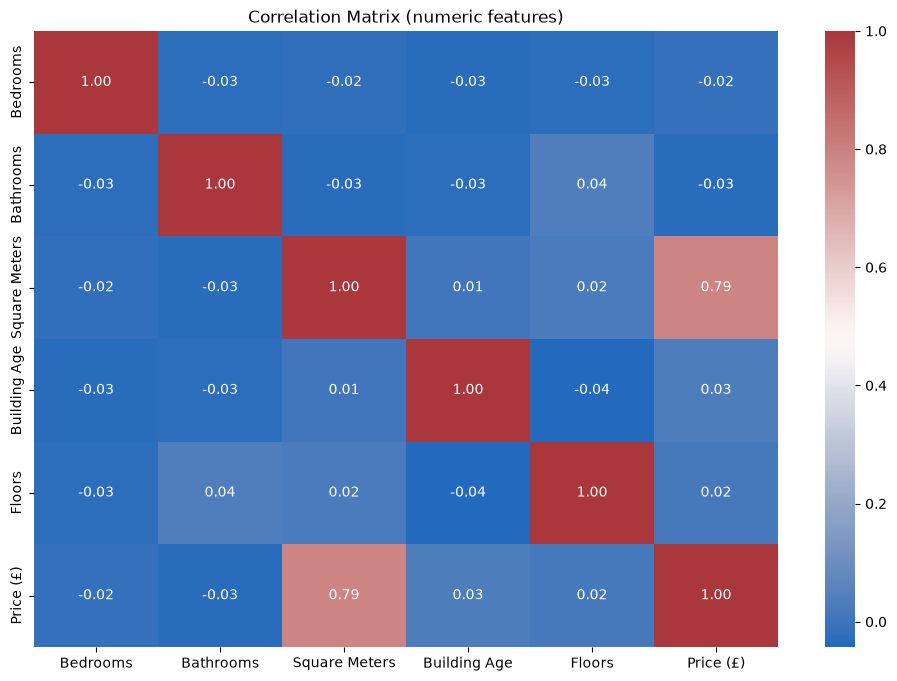

In [15]:
# Correlation heatmap for numeric features
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(12,8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag")
plt.title("Correlation Matrix (numeric features)")
plt.show()

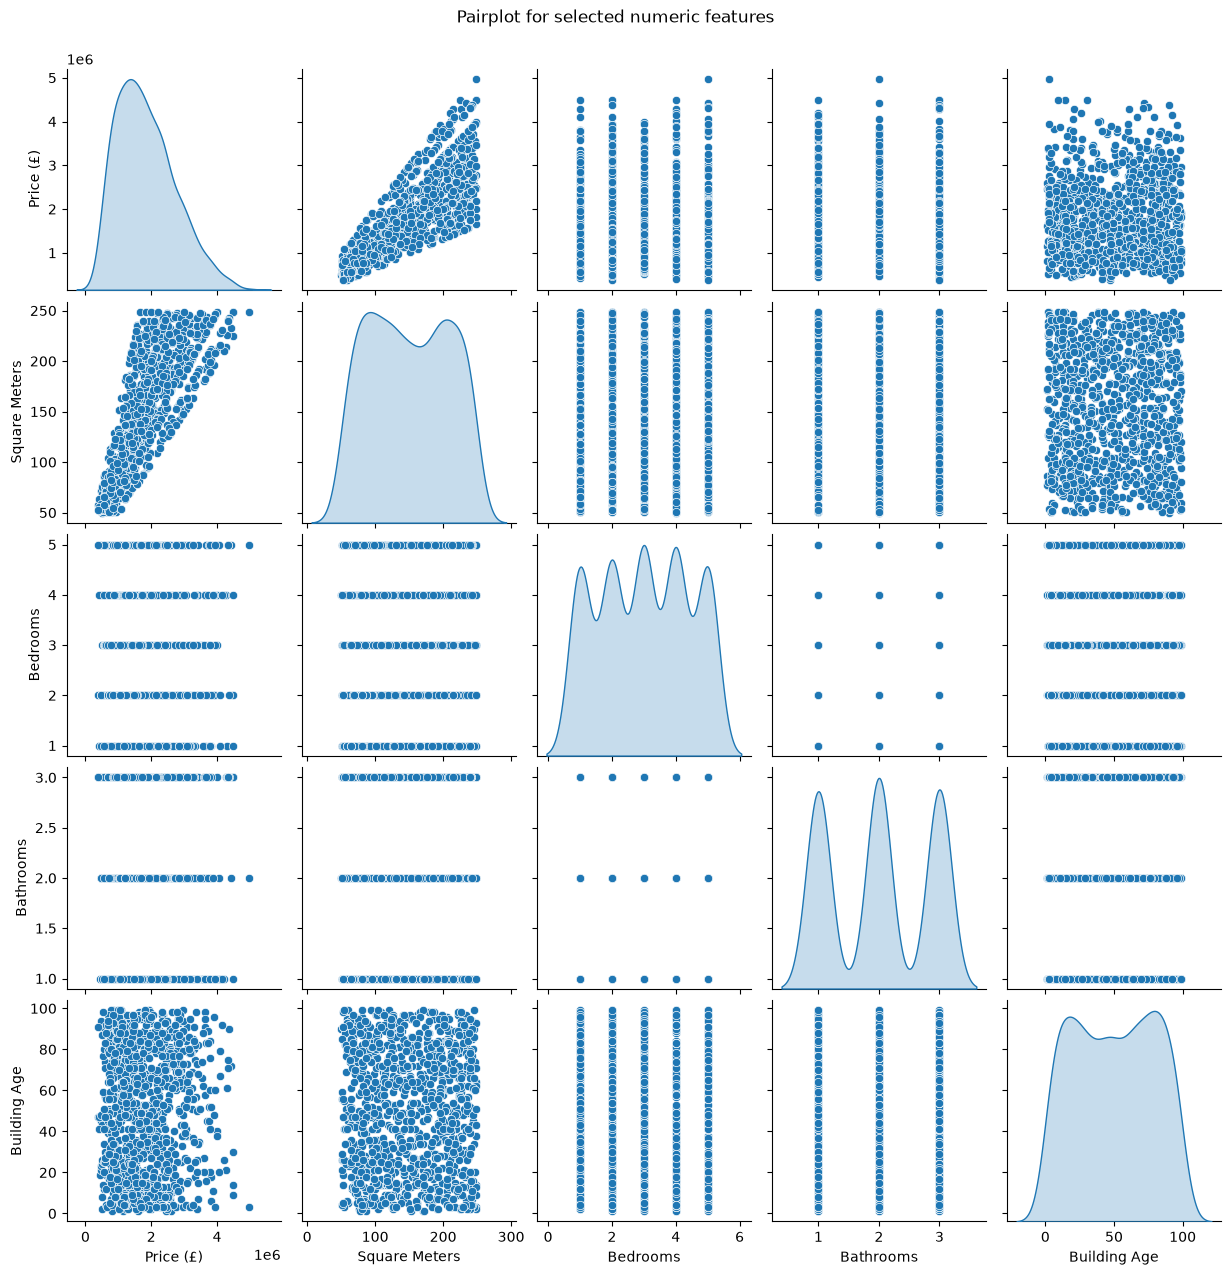

In [16]:
# Pairwise scatter for a few key numeric features (pairplot)
pair_cols = ["Price (£)", "Square Meters", "Bedrooms", "Bathrooms", "Building Age"]
sns.pairplot(df[pair_cols], diag_kind="kde")
plt.suptitle("Pairplot for selected numeric features", y=1.02)
plt.show()


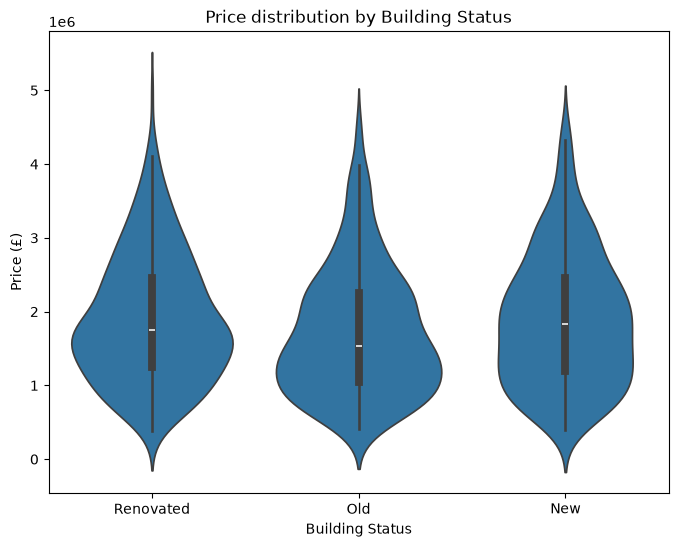

In [17]:
# Violin plot: Price distribution by Building Status
plt.figure(figsize=(8,6))
sns.violinplot(data=df, x="Building Status", y="Price (£)")
plt.title("Price distribution by Building Status")
plt.show()

In [18]:
X = df.drop(columns=["Price (£)", "Address"], errors="ignore")
y = df["Price (£)"].copy()

In [19]:
# Identify categorical columns (object / category) and numeric
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

C:\Users\ABXREHMAN\AppData\Local\Temp\ipykernel_8664\3214365498.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()


In [20]:
print("\nCategorical cols:", cat_cols)
print("Numeric cols:", num_cols)


Categorical cols: ['Neighborhood', 'Garden', 'Garage', 'Property Type', 'Heating Type', 'Balcony', 'Interior Style', 'View', 'Materials', 'Building Status']
Numeric cols: ['Bedrooms', 'Bathrooms', 'Square Meters', 'Building Age', 'Floors']


## **4. One Hot Encoding**

In [21]:
# One-hot encode categorical columns (drop_first to avoid multicollinearity)
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [22]:
print("\nFeature matrix shape after encoding:", X_encoded.shape)
display(X_encoded.head())


Feature matrix shape after encoding: (1000, 35)


,Bedrooms,Bathrooms,Square Meters,Building Age,Floors,Neighborhood_Chelsea,Neighborhood_Greenwich,Neighborhood_Islington,Neighborhood_Kensington,Neighborhood_Marylebone,...,Interior Style_Modern,View_Garden,View_Park,View_Sea,View_Street,Materials_Laminate Flooring,Materials_Marble,Materials_Wood,Building Status_Old,Building Status_Renovated
0,2,3,179,72,3,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,True
1,2,1,123,34,1,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
2,5,3,168,38,3,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,True
3,5,1,237,53,1,False,False,True,False,False,...,False,False,True,False,False,False,False,False,False,True
4,4,1,127,23,2,False,False,False,False,True,...,True,False,True,False,False,False,False,True,True,False


## **5. Standardization**

In [23]:
# OPTIONAL: SCALE NUMERIC FEATURES (for models that need it)
scaler = StandardScaler()
X_scaled = X_encoded.copy()
X_scaled[num_cols] = scaler.fit_transform(X_scaled[num_cols])

## **6. Train Test Split**

In [24]:
# TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (700, 35) Test shape: (300, 35)


## **7. Linear Regression Model**

In [25]:
# MODEL 1: Linear Regression (baseline)
# -----------------------------
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [26]:
def print_regression_results(model_name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{model_name} results:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE : {mae:.2f}")
    print(f"  R2  : {r2:.3f}")

print_regression_results("Linear Regression", y_test, y_pred_lr)


Linear Regression results:
  RMSE: 213800.02
  MAE : 160517.79
  R2  : 0.943


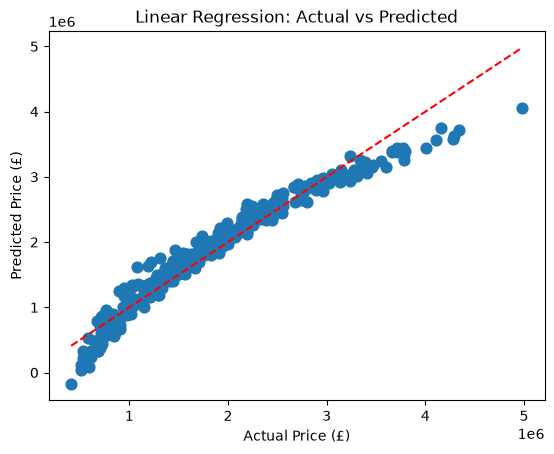

In [27]:
# Predicted vs Actual scatter (Linear Regression)
plt.figure()
plt.scatter(y_test, y_pred_lr, s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Price (£)")
plt.ylabel("Predicted Price (£)")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

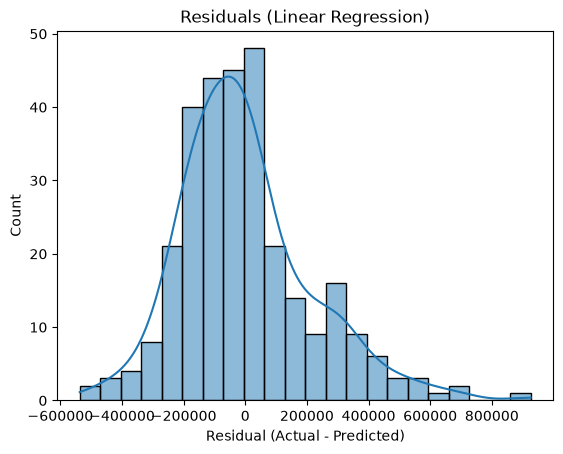

In [28]:
# Residuals plot (Linear Regression)
residuals_lr = y_test - y_pred_lr
plt.figure()
sns.histplot(residuals_lr, kde=True)
plt.title("Residuals (Linear Regression)")
plt.xlabel("Residual (Actual - Predicted)")
plt.show()

## **8. Random Forest Model**

In [29]:
# MODEL 2: Random Forest Regressor (stronger baseline)
# -----------------------------
rf = RandomForestRegressor(
    n_estimators=600,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print_regression_results("Random Forest", y_test, y_pred_rf)


Random Forest results:
  RMSE: 188185.32
  MAE : 144164.48
  R2  : 0.955


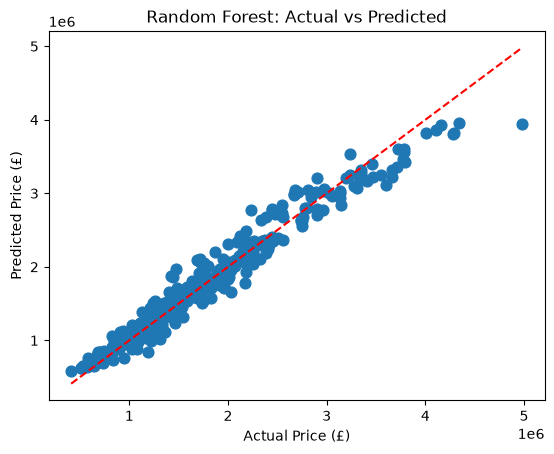

In [30]:
# Predicted vs Actual scatter (Random Forest)
plt.figure()
plt.scatter(y_test, y_pred_rf, s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Price (£)")
plt.ylabel("Predicted Price (£)")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

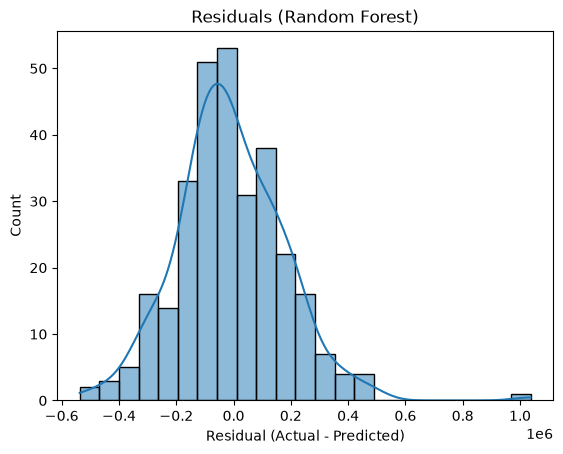

In [31]:
# Residuals plot (Random Forest)
residuals_rf = y_test - y_pred_rf
plt.figure()
sns.histplot(residuals_rf, kde=True)
plt.title("Residuals (Random Forest)")
plt.xlabel("Residual (Actual - Predicted)")
plt.show()

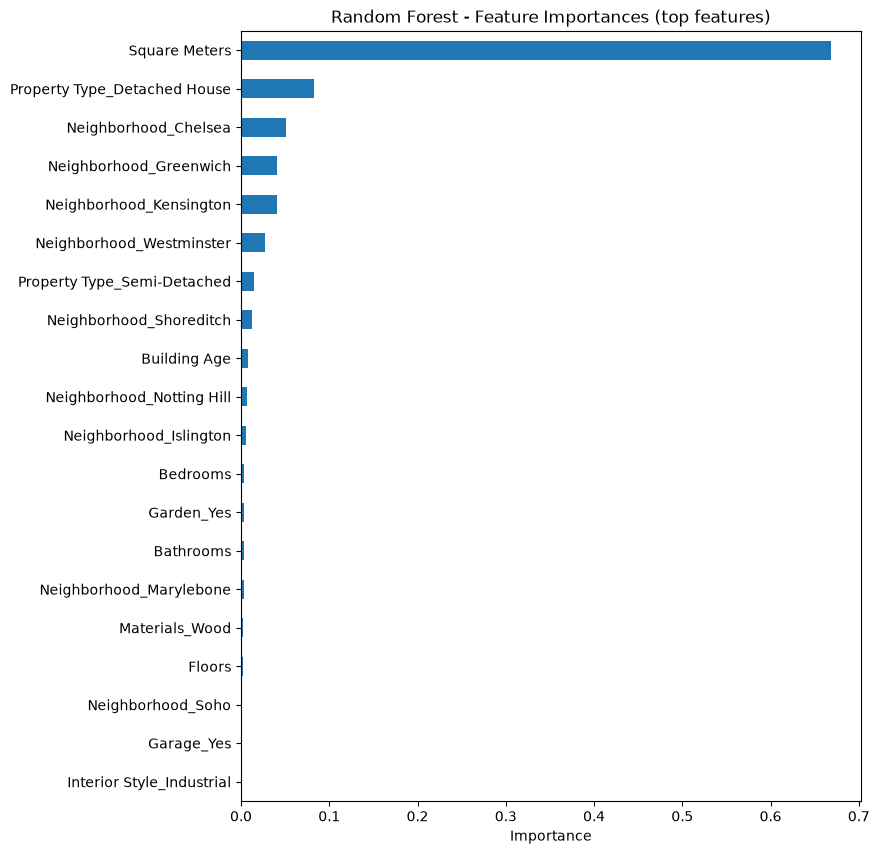

In [32]:
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)

plt.figure(figsize=(8,10))
feat_imp.tail(20).plot(kind="barh")
plt.title("Random Forest - Feature Importances (top features)")
plt.xlabel("Importance")
plt.show()

## 9. XGB Regressor

In [33]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [34]:
y_pred = model.predict(X_test)

# --------------------------
# 5. MODEL EVALUATION
# --------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [35]:
print("XGBoost Results:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

XGBoost Results:
MAE: 58545.98828125
RMSE: 89175.28195638071
R² Score: 0.9900060892105103


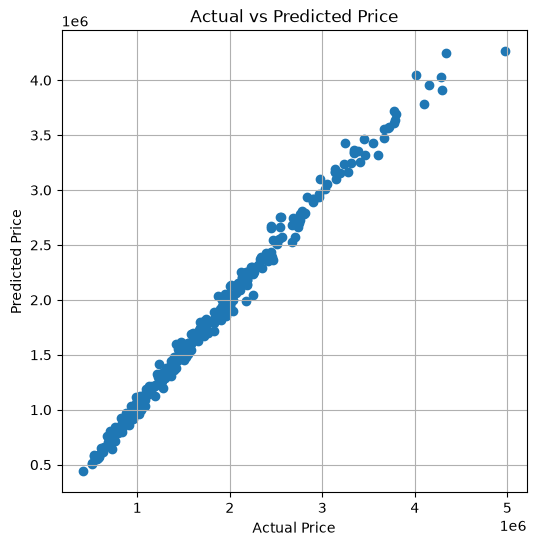

In [36]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.grid()
plt.show()

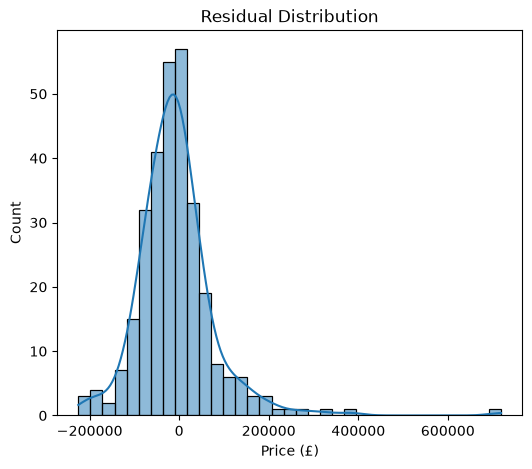

In [37]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

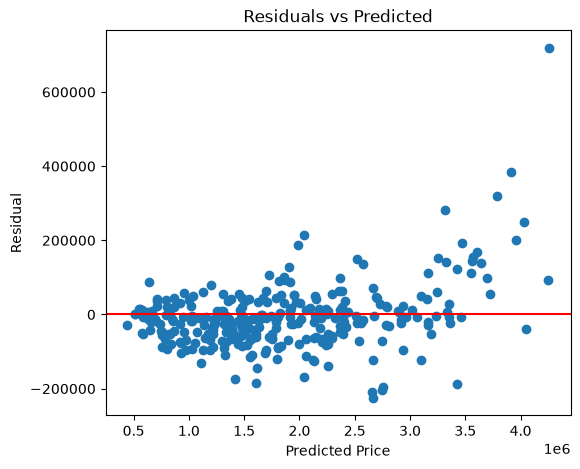

In [38]:
plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.title("Residuals vs Predicted")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.show()


# **Conclusion**

Among all the models tested, XGBoost delivered the highest accuracy and lowest error, proving it handles the dataset’s non-linear relationships far better than linear models. Its ability to learn complex patterns and feature interactions makes it the best-performing model for price prediction in this dataset.